# Chicago Crime Data Explorer

Runs each analytical query in [`sql/queries.sql`](../sql/queries.sql) against the normalized
SQLite database and charts the result.

**Data:** Chicago Police Department incidents from the City of Chicago Data Portal,
2024-09-01 to 2026-08-31 (478,074 incidents).
Build the database first with `python scripts/fetch_data.py && python scripts/load_data.py`.

In [1]:
import re
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT = ROOT / "output"
OUTPUT.mkdir(exist_ok=True)

conn = sqlite3.connect(ROOT / "crime.db")

# Load every "-- name: ..." block from queries.sql into a dict.
QUERIES = {
    block.split("\n", 1)[0].strip(): block.split("\n", 1)[1]
    for block in re.split(r"^-- name: ", (ROOT / "sql" / "queries.sql").read_text(), flags=re.M)[1:]
}

def run(name):
    """Run a named query and return the result as a DataFrame."""
    return pd.read_sql(QUERIES[name], conn)

def show_sql(name):
    print(QUERIES[name].strip())

BLUE, LIGHT_BLUE, ORANGE, GREY = "#2f6db5", "#a9c4e6", "#d9822b", "#8a8f98"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})

def save(fig, name):
    fig.savefig(OUTPUT / f"{name}.png")

## 1. When during the day are incidents recorded?

About 3.7% of incidents are timestamped exactly **00:00:00** and 2.2% exactly **12:00:00**,
far more than any other single minute. These are most likely placeholders for an unknown time,
so they are shown in a lighter shade rather than counted as real midnight or noon activity.

In [2]:
show_sql("incidents_by_hour")

-- When during the day are incidents recorded? Timestamps of exactly 00:00:00
-- and 12:00:00 are counted separately: they are far more common than any
-- other minute and are likely placeholders for "time unknown".
SELECT
    CAST(strftime('%H', occurred_at) AS INTEGER)                   AS hour,
    COUNT(*)                                                       AS incidents,
    SUM(time(occurred_at) IN ('00:00:00', '12:00:00'))             AS placeholder_time,
    COUNT(*) - SUM(time(occurred_at) IN ('00:00:00', '12:00:00'))  AS exact_time
FROM incidents
GROUP BY hour
ORDER BY hour;


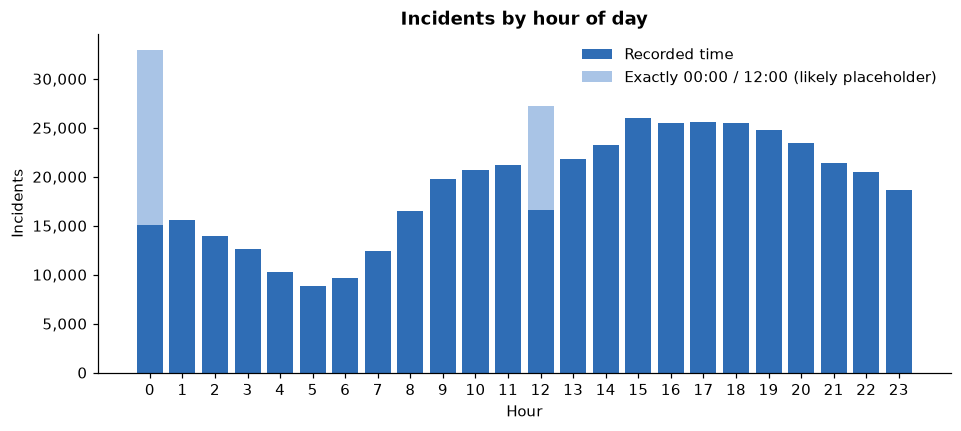

Peak hour (recorded times): 15:00 with 26,044 incidents
Quietest hour: 5:00 with 8,842 incidents (2.9x fewer than the peak)


In [3]:
by_hour = run("incidents_by_hour")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour.hour, by_hour.exact_time, color=BLUE, label="Recorded time")
ax.bar(by_hour.hour, by_hour.placeholder_time, bottom=by_hour.exact_time,
       color=LIGHT_BLUE, label="Exactly 00:00 / 12:00 (likely placeholder)")
ax.set(title="Incidents by hour of day", xlabel="Hour", ylabel="Incidents",
       xticks=range(24))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False)
save(fig, "01_incidents_by_hour")
plt.show()

peak = by_hour.loc[by_hour.exact_time.idxmax()]
low = by_hour.loc[by_hour.exact_time.idxmin()]
print(f"Peak hour (recorded times): {peak.hour}:00 with {peak.exact_time:,} incidents")
print(f"Quietest hour: {low.hour}:00 with {low.exact_time:,} incidents "
      f"({peak.exact_time / low.exact_time:.1f}x fewer than the peak)")

## 2. Top crime categories by police district

The three most common categories in each district, as a share of that district's incidents.
Blank cells mean the category is not in that district's top three.
District 31 (31 incidents) and district 61 (638 incidents, not in the city's district
boundary file) are left out of the chart because their volumes are too small to compare.

In [4]:
show_sql("top_categories_by_district")

-- The three most common crime categories in each police district, and what
-- share of that district's incidents each one makes up.
WITH district_counts AS (
    SELECT i.district_id, c.name AS category, COUNT(*) AS incidents
    FROM incidents i
    JOIN incident_types t   USING (iucr)
    JOIN crime_categories c USING (category_id)
    GROUP BY i.district_id, c.name
),
ranked AS (
    SELECT
        district_id,
        category,
        incidents,
        ROUND(100.0 * incidents / SUM(incidents) OVER (PARTITION BY district_id), 1) AS pct_of_district,
        ROW_NUMBER() OVER (PARTITION BY district_id ORDER BY incidents DESC)          AS rank
    FROM district_counts
)
SELECT r.district_id, d.name AS district, r.rank, r.category, r.incidents, r.pct_of_district
FROM ranked r
JOIN districts d USING (district_id)
WHERE r.rank <= 3
ORDER BY r.district_id, r.rank;


,district_id,district,rank,category,incidents,pct_of_district
0,1,1ST,1,THEFT,9186,33.9
1,1,1ST,2,BATTERY,3757,13.9
2,1,1ST,3,DECEPTIVE PRACTICE,2316,8.5
3,2,2ND,1,THEFT,5964,23.1
4,2,2ND,2,BATTERY,4378,17.0
5,2,2ND,3,CRIMINAL DAMAGE,3395,13.2
6,3,3RD,1,BATTERY,5624,21.9
7,3,3RD,2,THEFT,4239,16.5
8,3,3RD,3,CRIMINAL DAMAGE,3164,12.3


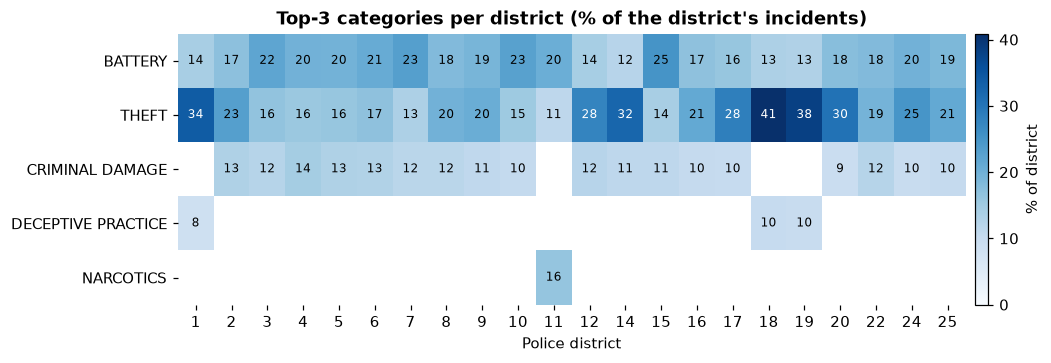

In [5]:
top = run("top_categories_by_district")
display(top.head(9))

geo = top[~top.district_id.isin([31, 61])]
heat = geo.pivot(index="category", columns="district_id", values="pct_of_district")
heat = heat.loc[heat.notna().sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(heat.values, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(heat.shape[1]), heat.columns)
ax.set_yticks(range(heat.shape[0]), heat.index)
ax.set_xlabel("Police district")
for (r, c), v in pd.DataFrame(heat.values).stack().items():
    if pd.isna(v):
        continue
    ax.text(c, r, f"{v:.0f}", ha="center", va="center", fontsize=8,
            color="white" if v > 25 else "black")
ax.set_title("Top-3 categories per district (% of the district's incidents)")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, label="% of district", pad=0.01)
save(fig, "02_top_categories_by_district")
plt.show()

## 3. Month-over-month trend

Monthly incident counts, with the second year (Sep 2025 to Aug 2026) plotted over the first
(Sep 2024 to Aug 2025) so each month can be compared with the same month a year earlier.

In [6]:
show_sql("monthly_trend")

-- Incidents per month with month-over-month and year-over-year change.
WITH monthly AS (
    SELECT strftime('%Y-%m', occurred_at) AS month, COUNT(*) AS incidents
    FROM incidents
    GROUP BY month
)
SELECT
    month,
    incidents,
    ROUND(100.0 * (incidents - LAG(incidents) OVER w) / LAG(incidents) OVER w, 1)
        AS mom_pct_change,
    LAG(incidents, 12) OVER w AS same_month_last_year,
    ROUND(100.0 * (incidents - LAG(incidents, 12) OVER w) / LAG(incidents, 12) OVER w, 1)
        AS yoy_pct_change
FROM monthly
WINDOW w AS (ORDER BY month)
ORDER BY month;


,month,incidents,mom_pct_change,same_month_last_year,yoy_pct_change
0,2024-09,23030,NaN,NaN,NaN
1,2024-10,22522,-2.2,NaN,NaN
2,2024-11,19769,-12.2,NaN,NaN
3,2024-12,19651,-0.6,NaN,NaN
4,2025-01,18566,-5.5,NaN,NaN
5,2025-02,16581,-10.7,NaN,NaN
6,2025-03,19827,19.6,NaN,NaN
7,2025-04,19728,-0.5,NaN,NaN
8,2025-05,20565,4.2,NaN,NaN
9,2025-06,21187,3.0,NaN,NaN


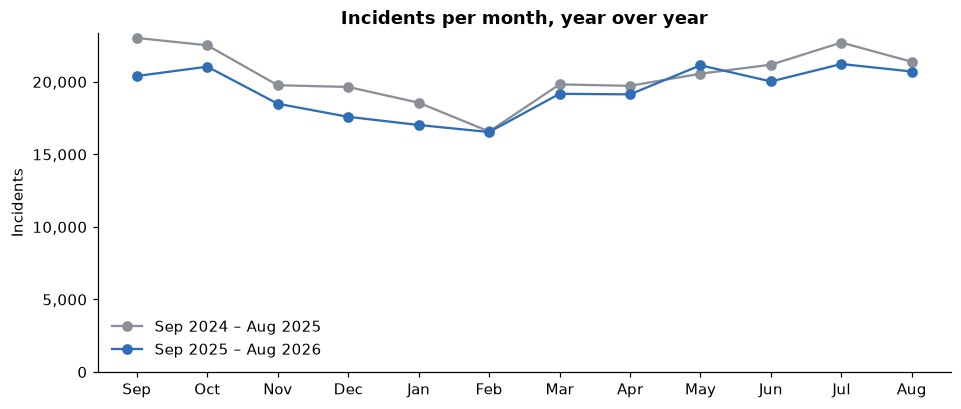

Year 1 total: 245,524   Year 2 total: 232,550   change: -5.3%
Months where year 2 was lower than year 1: 11 of 12


In [7]:
monthly = run("monthly_trend")
display(monthly)

year1, year2 = monthly.iloc[:12], monthly.iloc[12:]
labels = pd.to_datetime(year1.month).dt.strftime("%b")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(labels, year1.incidents, marker="o", color=GREY, label="Sep 2024 – Aug 2025")
ax.plot(labels, year2.incidents.values, marker="o", color=BLUE, label="Sep 2025 – Aug 2026")
ax.set(title="Incidents per month, year over year", ylabel="Incidents", ylim=(0, None))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False, loc="lower left")
save(fig, "03_monthly_trend")
plt.show()

change = year2.incidents.sum() / year1.incidents.sum() - 1
print(f"Year 1 total: {year1.incidents.sum():,}   Year 2 total: {year2.incidents.sum():,}   "
      f"change: {change:+.1%}")
print(f"Months where year 2 was lower than year 1: {(year2.yoy_pct_change < 0).sum()} of 12")

## 4. Average incidents per day of week

Average incidents per calendar day for each weekday. The whiskers show the lowest and highest
single day seen for that weekday.

In [8]:
show_sql("avg_per_day_of_week")

-- Average incidents per calendar day, by day of week. Averaging over dates
-- (rather than summing) corrects for weekdays that occur more often in the
-- two-year window.
WITH daily AS (
    SELECT date(occurred_at) AS day, COUNT(*) AS incidents
    FROM incidents
    GROUP BY day
)
SELECT
    CAST(strftime('%w', day) AS INTEGER) AS dow,  -- 0 = Sunday
    CASE strftime('%w', day)
        WHEN '0' THEN 'Sun' WHEN '1' THEN 'Mon' WHEN '2' THEN 'Tue'
        WHEN '3' THEN 'Wed' WHEN '4' THEN 'Thu' WHEN '5' THEN 'Fri'
        ELSE 'Sat'
    END                        AS day_of_week,
    COUNT(*)                   AS days,
    ROUND(AVG(incidents), 1)   AS avg_incidents,
    MIN(incidents)             AS min_incidents,
    MAX(incidents)             AS max_incidents
FROM daily
GROUP BY dow
ORDER BY dow;


,dow,day_of_week,days,avg_incidents,min_incidents,max_incidents
0,0,Sun,105,653.7,423,948
1,1,Mon,105,655.9,480,791
2,2,Tue,104,643.4,479,857
3,3,Wed,104,645.3,464,902
4,4,Thu,104,641.2,418,834
5,5,Fri,104,676.8,463,905
6,6,Sat,104,668.0,451,807


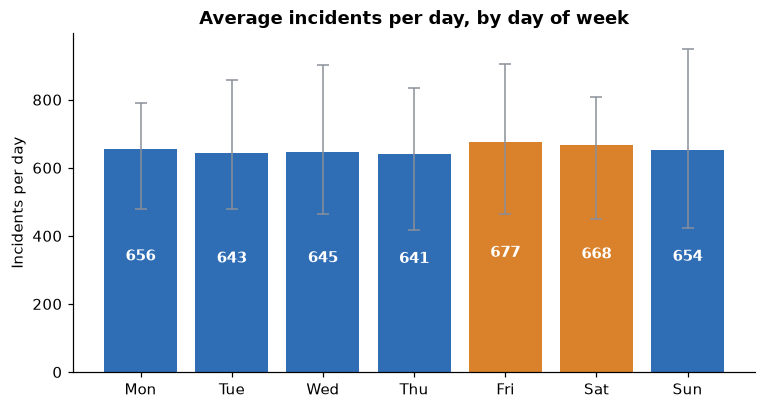

Busiest weekday is only 5.6% above the quietest.


In [9]:
dow = run("avg_per_day_of_week")
display(dow)

order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = dow.set_index("day_of_week").loc[order].reset_index()
err = [dow.avg_incidents - dow.min_incidents, dow.max_incidents - dow.avg_incidents]

fig, ax = plt.subplots(figsize=(8, 4))
colors = [ORANGE if d in ("Fri", "Sat") else BLUE for d in dow.day_of_week]
ax.bar(dow.day_of_week, dow.avg_incidents, color=colors, yerr=err,
       error_kw=dict(ecolor=GREY, capsize=4, lw=1))
for x, v in enumerate(dow.avg_incidents):
    ax.text(x, v / 2, f"{v:.0f}", ha="center", color="white", fontweight="bold")
ax.set(title="Average incidents per day, by day of week", ylabel="Incidents per day")
save(fig, "04_avg_per_day_of_week")
plt.show()

spread = dow.avg_incidents.max() / dow.avg_incidents.min() - 1
print(f"Busiest weekday is only {spread:.1%} above the quietest.")

## 5. Arrest rate by crime category

Share of incidents in each category (with at least 1,000 incidents) where an arrest was made.

In [10]:
show_sql("arrest_rate_by_category")

-- Share of incidents that resulted in an arrest, for categories with at least
-- 1,000 incidents in the window.
SELECT
    c.name                               AS category,
    COUNT(*)                             AS incidents,
    SUM(i.arrest)                        AS arrests,
    ROUND(100.0 * SUM(i.arrest) / COUNT(*), 1) AS arrest_rate_pct
FROM incidents i
JOIN incident_types t   USING (iucr)
JOIN crime_categories c USING (category_id)
GROUP BY c.name
HAVING COUNT(*) >= 1000
ORDER BY arrest_rate_pct DESC;


,category,incidents,arrests,arrest_rate_pct
0,NARCOTICS,13811,13242,95.9
1,INTERFERENCE WITH PUBLIC OFFICER,1829,1667,91.1
2,WEAPONS VIOLATION,11075,8361,75.5
3,PUBLIC PEACE VIOLATION,2228,1176,52.8
4,CRIMINAL TRESPASS,10738,3438,32.0
5,OTHER OFFENSE,32913,6289,19.1
6,BATTERY,86286,16294,18.9
7,ASSAULT,43114,5465,12.7
8,ROBBERY,11955,1132,9.5
9,THEFT,109012,9583,8.8


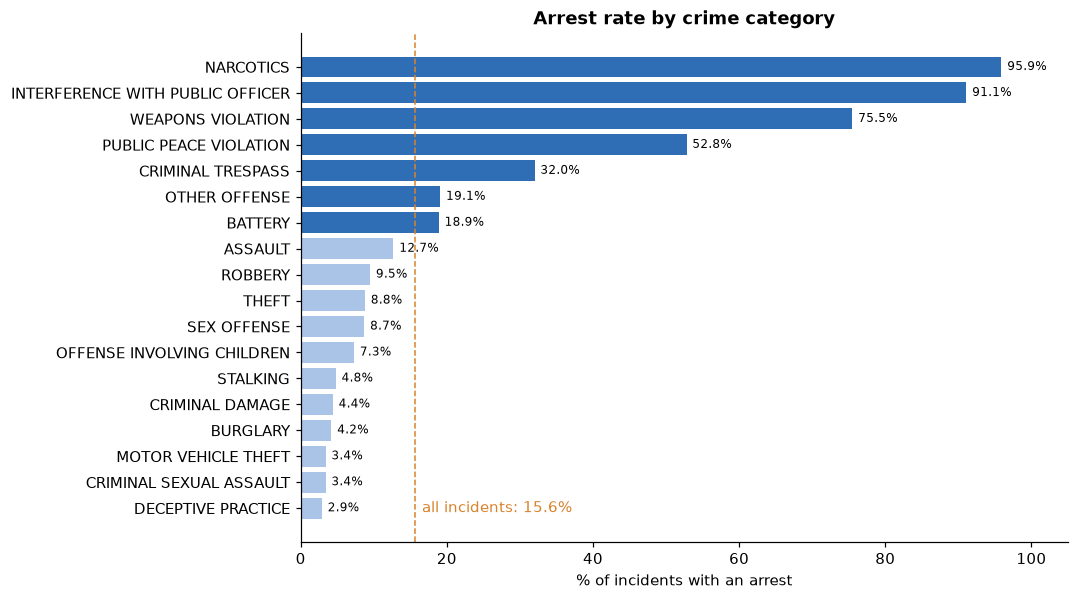

In [11]:
arrests = run("arrest_rate_by_category")
display(arrests)

overall = pd.read_sql("SELECT ROUND(100.0 * AVG(arrest), 1) AS pct FROM incidents", conn).pct[0]
data = arrests.sort_values("arrest_rate_pct")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(data.category, data.arrest_rate_pct,
        color=[BLUE if v >= overall else LIGHT_BLUE for v in data.arrest_rate_pct])
ax.axvline(overall, color=ORANGE, ls="--", lw=1)
ax.text(overall + 1, 0, f"all incidents: {overall}%", color=ORANGE, va="center")
for y, v in enumerate(data.arrest_rate_pct):
    ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=8)
ax.set(title="Arrest rate by crime category", xlabel="% of incidents with an arrest", xlim=(0, 105))
save(fig, "05_arrest_rate_by_category")
plt.show()

## 6. Community areas: volume and domestic share

The 15 community areas with the most incidents, split into incidents flagged as
domestic-related and all others. Incidents with an unknown community area (664) are excluded.

In [12]:
show_sql("community_areas_domestic_share")

-- The 15 community areas with the most incidents, with the share of those
-- incidents flagged as domestic-related.
SELECT
    ca.name                                        AS community_area,
    COUNT(*)                                       AS incidents,
    SUM(i.domestic)                                AS domestic,
    ROUND(100.0 * SUM(i.domestic) / COUNT(*), 1)   AS domestic_pct
FROM incidents i
JOIN community_areas ca USING (community_area_id)
GROUP BY ca.community_area_id
ORDER BY incidents DESC
LIMIT 15;


,community_area,incidents,domestic,domestic_pct
0,AUSTIN,24049,6518,27.1
1,NEAR NORTH SIDE,21827,1503,6.9
2,NEAR WEST SIDE,21104,2242,10.6
3,LOOP,16867,680,4.0
4,SOUTH SHORE,16444,4584,27.9
5,WEST TOWN,14521,1140,7.9
6,HUMBOLDT PARK,12722,2338,18.4
7,NORTH LAWNDALE,12626,3126,24.8
8,GREATER GRAND CROSSING,12295,3460,28.1
9,LAKE VIEW,12275,682,5.6


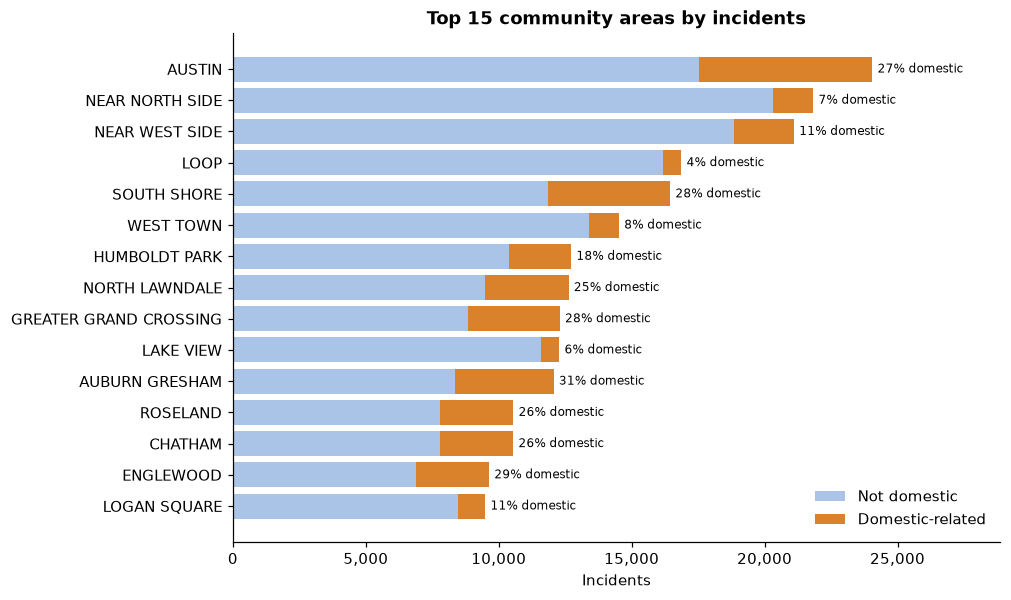

In [13]:
areas = run("community_areas_domestic_share")
display(areas)

data = areas.iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(data.community_area, data.incidents - data.domestic, color=LIGHT_BLUE, label="Not domestic")
ax.barh(data.community_area, data.domestic, left=data.incidents - data.domestic,
        color=ORANGE, label="Domestic-related")
for y, (n, pct) in enumerate(zip(data.incidents, data.domestic_pct)):
    ax.text(n + 200, y, f"{pct:.0f}% domestic", va="center", fontsize=8)
ax.set(title="Top 15 community areas by incidents", xlabel="Incidents", xlim=(0, data.incidents.max() * 1.2))
ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.legend(frameon=False, loc="lower right")
save(fig, "06_community_areas_domestic_share")
plt.show()

In [14]:
conn.close()